# Phase 3 - Notebook 05: MASt3R: Matching-Aware Stereo Transformer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase3/05_mast3r_extension.ipynb)


## Setup


In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Setup complete!")

Setup complete!


## 1. MASt3R：DUSt3R 的改进

虽然 DUSt3R 很强大，但有几个局限：

1. **匹配不确定性**：网络输出 Pointmaps，但对匹配的置信度表示不清楚
2. **局部特征**：没有显式的局部特征匹配
3. **多视图扩展**：对 >2 视图的扩展性不好

**MASt3R (Matching-Aware Stereo 3D Reconstruction)** 改进了这些方面：

```
DUSt3R:                          MASt3R:
Image Pair                       Image Pair
    ↓                               ↓
ViT + Cross-Attn                ViT + Cross-Attn
    ↓                               ↓
Pointmaps                       Pointmaps + 匹配头
                                    ↓
                                密集特征匹配
                                    ↓
                                更精确的对应关系
```


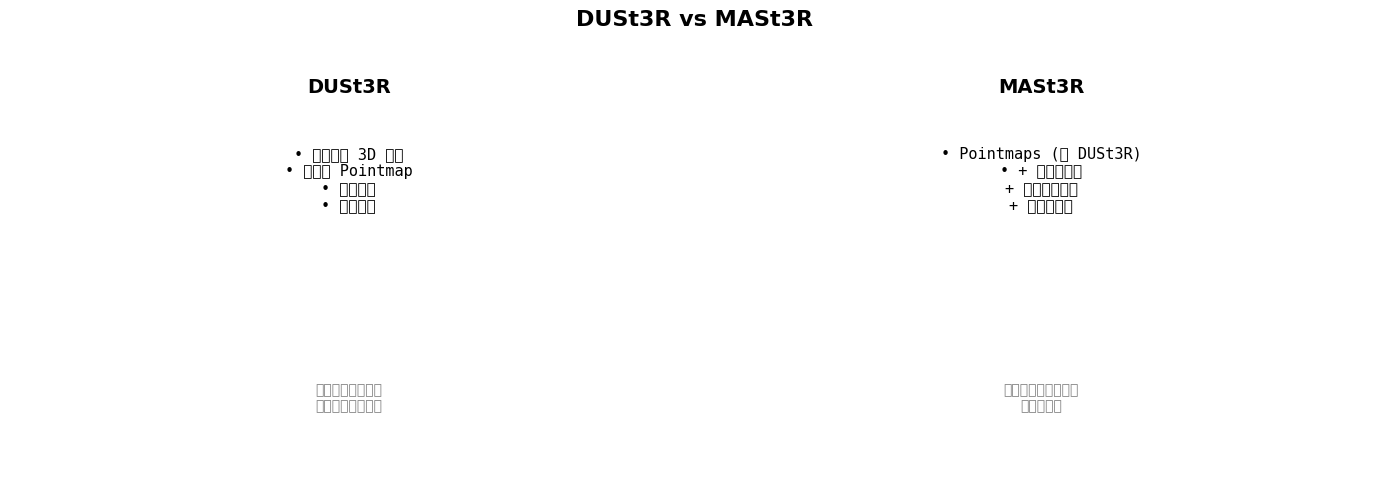

In [2]:
# 比较 DUSt3R 和 MASt3R
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.text(0.5, 0.9, 'DUSt3R', ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.7, '• 直接预测 3D 坐标\n• 端到端 Pointmap\n• 置信度图\n• 快速推理',
        ha='center', va='center', fontsize=11, transform=ax.transAxes, family='monospace')
ax.text(0.5, 0.2, '优点：简单、快速\n缺点：无显式匹配',
        ha='center', va='center', fontsize=10, color='gray', transform=ax.transAxes, style='italic')
ax.axis('off')

ax = axes[1]
ax.text(0.5, 0.9, 'MASt3R', ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.7, '• Pointmaps (如 DUSt3R)\n• + 显式匹配头\n+ 密集特征描述\n+ 匹配置信度',
        ha='center', va='center', fontsize=11, transform=ax.transAxes, family='monospace')
ax.text(0.5, 0.2, '优点：更精确的对应\n缺点：稍慢',
        ha='center', va='center', fontsize=10, color='gray', transform=ax.transAxes, style='italic')
ax.axis('off')

plt.suptitle('DUSt3R vs MASt3R', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('dust3r_vs_mast3r.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. MASt3R 的匹配头

MASt3R 添加了一个**匹配头**来学习密集的特征描述符：

```
交叉注意力输出
      ↓
  匹配头 (Linear + 归一化)
      ↓
  密集特征描述 [B, H, W, D_match]
      ↓
  计算特征相似度
      ↓
  对应关系矩阵
```


In [3]:
class MASt3RMatchingHead(torch.nn.Module):
    """MASt3R 的匹配头。"""
    
    def __init__(self, embed_dim, match_dim=128):
        super().__init__()
        self.proj = torch.nn.Linear(embed_dim, match_dim)
        self.match_dim = match_dim
    
    def forward(self, feat1, feat2):
        """
        计算特征匹配分数。
        
        Args:
            feat1: [B, N, D]
            feat2: [B, N, D]
        
        Returns:
            match_scores: [B, N, N] 匹配相似度
        """
        # 投影到匹配空间
        desc1 = torch.nn.functional.normalize(self.proj(feat1), dim=-1)  # [B, N, D_m]
        desc2 = torch.nn.functional.normalize(self.proj(feat2), dim=-1)
        
        # 计算相似度 (点积)
        match_scores = torch.bmm(desc1, desc2.transpose(1, 2))  # [B, N, N]
        
        return match_scores

print("MASt3R 匹配头定义完成")

MASt3R 匹配头定义完成


## 3. 多视图扩展

MASt3R 可以自然地扩展到多视图：

```
对于 N 张图像，执行所有图像对组合：

Frame 0 ↔ Frame 1  →  Pointmaps01, Matches01
Frame 0 ↔ Frame 2  →  Pointmaps02, Matches02
Frame 1 ↔ Frame 2  →  Pointmaps12, Matches12

然后：全局对齐 + 特征融合 → 一致的 3D 场景
```


In [4]:
# 演示多视图 MASt3R
print("多视图 MASt3R 工作流程：")
print()
print("输入: N=4 张图像")
print("步骤:")
print("  1. 对所有图像对运行 DUSt3R")
print("     → C(N, 2) = C(4, 2) = 6 个图像对")
print("  2. 每个图像对得到:")
print("     - Pointmaps")
print("     - Confidence 图")
print("     - 匹配矩阵（MASt3R）")
print("  3. 全局对齐:")
print("     - 使用 Procrustes 将相对位姿转换为全局位姿")
print("  4. 特征融合:")
print("     - 将所有视图的特征融合为统一表示")
print()
print("输出: 一致的全局 3D 场景")

多视图 MASt3R 工作流程：

输入: N=4 张图像
步骤:
  1. 对所有图像对运行 DUSt3R
     → C(N, 2) = C(4, 2) = 6 个图像对
  2. 每个图像对得到:
     - Pointmaps
     - Confidence 图
     - 匹配矩阵（MASt3R）
  3. 全局对齐:
     - 使用 Procrustes 将相对位姿转换为全局位姿
  4. 特征融合:
     - 将所有视图的特征融合为统一表示

输出: 一致的全局 3D 场景


## 4. 应用场景

MASt3R 特别适合：
1. **精细的 SfM**：需要精确匹配的场景
2. **动态场景**：利用匹配信息检测运动
3. **多视图几何**：利用一致的特征进行全局优化


## 5. Summary

**MASt3R 的关键改进：**
1. 保留 DUSt3R 的 Pointmap 输出
2. 添加显式的匹配头
3. 学习密集的特征描述符
4. 支持多视图扩展
5. 更精确的对应关系

---

**Next**: [06_code_walkthrough.ipynb](./06_code_walkthrough.ipynb)
